# E-Commerce Customer Segmentation, Churn & CLV Analysis

**Dataset:** [E-Commerce Customer Segmentation Dataset 2026 (Kaggle)](https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-segmentation-2026) — 50,000 customers × 53 features, including demographics, purchase behavior, engagement, RFM scores, CLV, profitability, and churn-risk labels.

## Business questions
1. **Who are our customers?** What natural segments emerge from behavior alone (K-Means), and how do they compare to the dataset's built-in segments?
2. **Who is at risk of churning**, and what actually predicts it?
3. **What drives customer lifetime value (CLV)**, and can we estimate it for a brand-new customer?
4. **Which customers should marketing prioritize**, and with what kind of campaign?

## Approach
1. Load, clean, and explore the data.
2. **Unsupervised segmentation** — K-Means clustering on raw behavioral features, validated with the elbow method and silhouette score, visualized with PCA.
3. **Churn prediction** — a classification model, deliberately tested two ways: with recency features (production-realistic) and without them (an "early warning" ablation that tests whether satisfaction/engagement/spend alone carry any signal).
4. **CLV prediction** — a regression model, likewise tested with full purchase history and in a "cold-start" version using only signals available for a brand-new customer.
5. **Marketing targeting model** — combine predicted churn risk × predicted CLV into an actionable 2×2 targeting matrix.
6. Translate findings into concrete recommendations.

> **A note on the data.** This is a synthetically generated dataset (see the correlation analysis in Section 2) — several fields are close to independent random draws, and a couple of relationships are deterministic by construction (e.g. `activity_status` is a direct banding of `days_since_last_purchase`). Rather than paper over that, this notebook calls it out explicitly wherever it changes how a result should be read — that kind of sanity-checking is exactly what you'd want to do before trusting a model on real business data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_curve, roc_auc_score, classification_report, r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression

pd.set_option('display.max_columns', None)
np.random.seed(42)

# --- consistent chart palette (colorblind-safe categorical order) ---
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
CAT = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
INK, INK2, MUTED, GRID, BASE, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, CRIT = "#0ca30c", "#d03b3b"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.linewidth": 0.6, "axes.grid": True, "axes.axisbelow": True,
})
SEQ_BLUE = LinearSegmentedColormap.from_list("seqblue", ["#cde2fb", "#2a78d6", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", [RED, "#f0efec", BLUE])
IMG_DIR = "images"


## 1. Load & inspect the data

In [2]:
df = pd.read_csv("data/E-commerce_Customer_Segmentation_2026.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 50,000 rows x 53 columns


,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,employment_type,marital_status,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,preferred_category_1,preferred_category_2,preferred_category_3,shopping_channel,device_used,payment_method,return_count,complaint_count,satisfaction_score,satisfaction_level,loyalty_tier,email_open_rate,click_through_rate,conversion_rate,social_media_presence,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,recency_score,frequency_score,monetary_score,rfm_score,churn_risk_score,customer_health_score,dataset_year,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,Unemployed,Widowed,77,28,912.60,25552.80,Quarterly,63,Sports & Fitness,Home & Kitchen,NaN,In-Store,Tablet,Debit Card,15,13,5,Very Satisfied,Platinum,0.018,0.067,0.022,NaN,21281.07,96.74,21184.33,3,3,4,10,39,100,2026,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,Student,Divorced,80,75,300.86,22564.50,Rarely,342,Automotive,Beauty,Fashion,Marketplace,Desktop,Bank Transfer,1,14,5,Very Satisfied,Gold,0.084,0.085,0.293,NaN,28347.21,199.28,28147.93,1,4,3,8,42,100,2026,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,Student,Married,86,163,663.91,108217.33,Quarterly,64,Fashion,Automotive,Beauty,In-Store,Tablet,Bank Transfer,1,4,3,Neutral,Diamond,0.279,0.428,0.222,NaN,103909.84,112.39,103797.45,3,5,5,13,0,100,2026,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV


In [3]:
print("Missing values:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
preferred_category_2     16743
preferred_category_3     33257
loyalty_tier              1272
social_media_presence    12420
dtype: int64

Duplicate rows: 0


Missing values are all *structurally* missing, not data-quality problems: not every customer has a 2nd/3rd preferred category, some have no `social_media_presence`, and 1,272 customers who never made a qualifying purchase have no `loyalty_tier`. No duplicate customers.

**Churn label.** The dataset doesn't ship a single `churned` flag, so we define one from `activity_status`: customers who are **Inactive** or **Dormant** (no purchase in 60+ days) are treated as churned; **Active** and **At Risk** are not.

In [4]:
df['churned'] = df['activity_status'].isin(['Inactive', 'Dormant']).astype(int)
print(f"Churn rate: {df['churned'].mean():.1%}")
df['activity_status'].value_counts().reindex(['Active','At Risk','Dormant','Inactive'])

Churn rate: 30.7%


activity_status
Active      29412
At Risk      5237
Dormant      4994
Inactive    10357
Name: count, dtype: int64

## 2. Exploratory data analysis

### 2.1 Activity status & churn overview

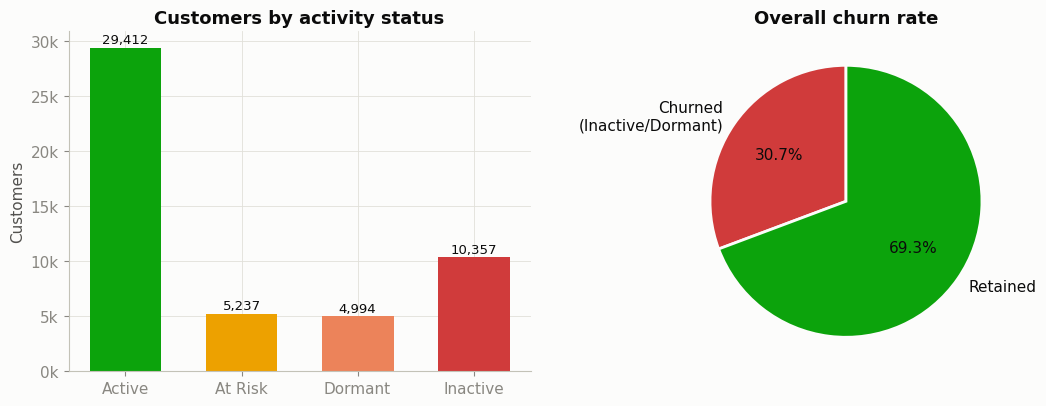

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
order = ['Active', 'At Risk', 'Dormant', 'Inactive']
counts = df['activity_status'].value_counts().reindex(order)
colors01 = [GOOD, YELLOW, "#ec835a", CRIT]
bars = axes[0].bar(counts.index, counts.values, color=colors01, width=0.62)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+400, f"{v:,}", ha='center', fontsize=9.5, color=INK)
axes[0].set_title("Customers by activity status")
axes[0].set_ylabel("Customers")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

churn_rate = df['churned'].mean()
axes[1].pie([churn_rate, 1-churn_rate], labels=["Churned\n(Inactive/Dormant)", "Retained"],
            colors=[CRIT, GOOD], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor=SURF, linewidth=2), textprops={'color': INK})
axes[1].set_title("Overall churn rate")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/01_activity_status_and_churn.png", dpi=150, bbox_inches="tight")
plt.show()

Nearly a third of the customer base (30.7%) has gone quiet — 60+ days since their last purchase. That's the group the churn and targeting models below are built to act on.

### 2.2 Spend & customer lifetime value

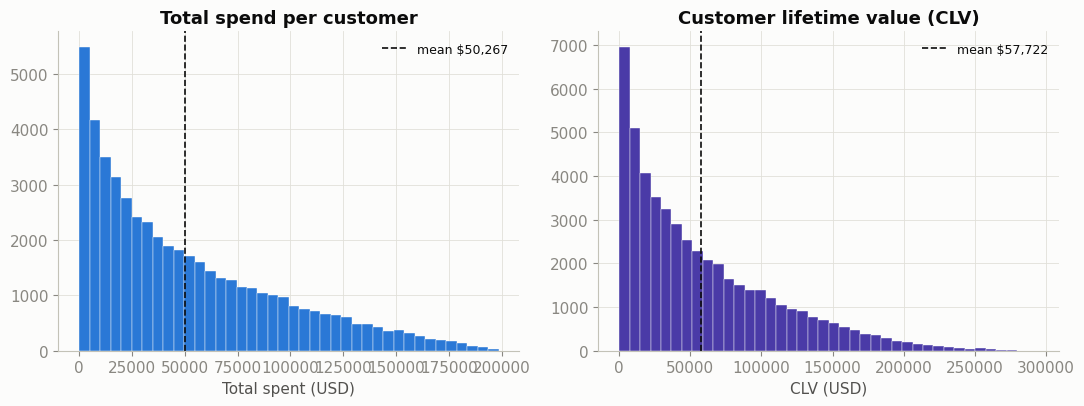

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(df['total_spent_usd'], bins=40, color=BLUE, edgecolor=SURF, linewidth=0.3)
axes[0].axvline(df['total_spent_usd'].mean(), color=INK, ls='--', lw=1.2, label=f"mean ${df['total_spent_usd'].mean():,.0f}")
axes[0].set_title("Total spend per customer"); axes[0].set_xlabel("Total spent (USD)")
axes[0].legend(frameon=False, fontsize=9)
axes[1].hist(df['customer_lifetime_value_usd'], bins=40, color=VIOLET, edgecolor=SURF, linewidth=0.3)
axes[1].axvline(df['customer_lifetime_value_usd'].mean(), color=INK, ls='--', lw=1.2, label=f"mean ${df['customer_lifetime_value_usd'].mean():,.0f}")
axes[1].set_title("Customer lifetime value (CLV)"); axes[1].set_xlabel("CLV (USD)")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/02_spend_and_clv_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Do behavioral & engagement signals actually relate to churn or value?

Before modeling anything, check simple correlations — this is what tells us later which "predictions" are genuinely learned vs. which are just recovering a formula.

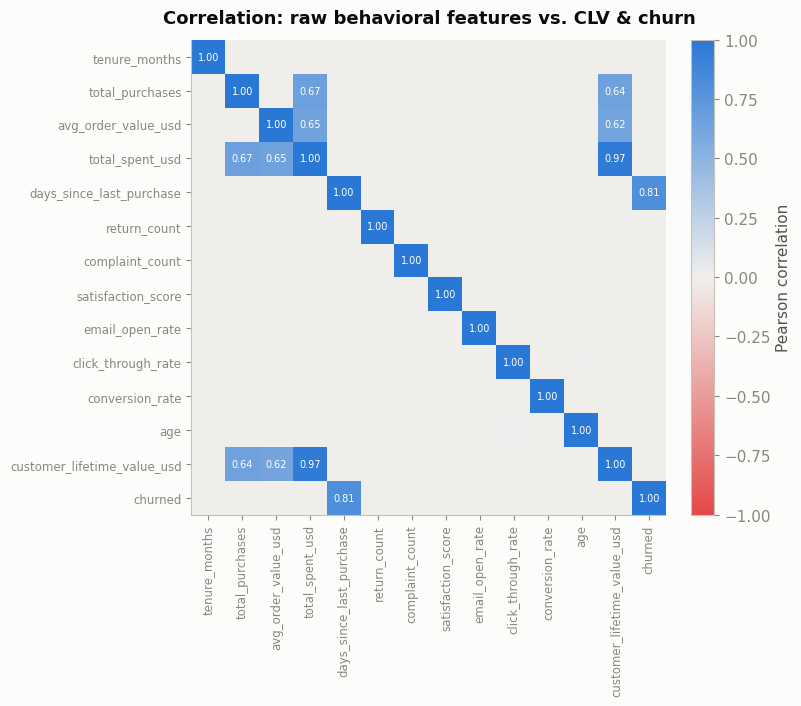

In [7]:
behavioral = ['tenure_months','total_purchases','avg_order_value_usd','total_spent_usd',
              'days_since_last_purchase','return_count','complaint_count','satisfaction_score',
              'email_open_rate','click_through_rate','conversion_rate','age',
              'customer_lifetime_value_usd','churned']
corr = df[behavioral].corr()
fig, ax = plt.subplots(figsize=(8.5, 7.2))
im = ax.imshow(corr, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(behavioral))); ax.set_xticklabels(behavioral, rotation=90, fontsize=8.5)
ax.set_yticks(range(len(behavioral))); ax.set_yticklabels(behavioral, fontsize=8.5)
for i in range(len(behavioral)):
    for j in range(len(behavioral)):
        v = corr.values[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7, color='white' if abs(v) > 0.6 else INK)
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Pearson correlation")
ax.set_title("Correlation: raw behavioral features vs. CLV & churn", pad=12)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Key observation:** almost every behavioral/engagement field — satisfaction, complaints, returns, email engagement, conversion rate — has essentially **zero correlation** with churn or CLV (|r| < 0.02). Only two relationships are strong, and both are structural:
- `days_since_last_purchase` ↔ `churned`: **r = 0.81** (expected — churn is *defined* from recency bands)
- `total_spent_usd` ↔ `customer_lifetime_value_usd`: **r = 0.97** (CLV is built almost entirely from historical spend)

This is the single most important finding to carry into the modeling sections: this dataset's "soft" signals (satisfaction, engagement, demographics) don't independently move the needle on churn or value. Every model below is designed to test that claim rather than assume it.

## 3. Customer segmentation — K-Means clustering

Rather than rely on the dataset's pre-built segments, we cluster customers from scratch using 11 raw behavioral/engagement features (tenure, purchase volume, order value, recency, returns, complaints, satisfaction, email/CTR/conversion, age), scaled with `StandardScaler`. `k` is chosen with the elbow method and silhouette score.

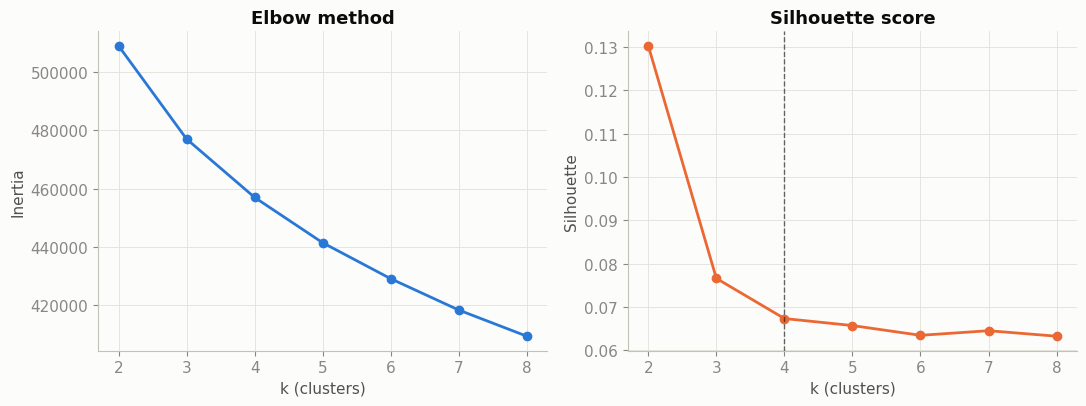

{2: np.float64(0.1303), 3: np.float64(0.0766), 4: np.float64(0.0674), 5: np.float64(0.0657), 6: np.float64(0.0635), 7: np.float64(0.0645), 8: np.float64(0.0633)}


In [8]:
clust_feats = ['tenure_months','total_purchases','avg_order_value_usd','days_since_last_purchase',
               'return_count','complaint_count','satisfaction_score','email_open_rate',
               'click_through_rate','conversion_rate','age']
Xs = StandardScaler().fit_transform(df[clust_feats])

ks = list(range(2, 9))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xs, km.labels_, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(ks, inertias, marker='o', color=BLUE, lw=2)
axes[0].set_title("Elbow method"); axes[0].set_xlabel("k (clusters)"); axes[0].set_ylabel("Inertia")
axes[1].plot(ks, sils, marker='o', color=ORANGE, lw=2)
axes[1].axvline(4, color=INK, ls='--', lw=1, alpha=0.6)
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k (clusters)"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/04_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print({k: round(s, 4) for k, s in zip(ks, sils)})

Silhouette peaks at **k=2** (0.13) — and that split is driven almost entirely by recency (active vs. dormant), which matches what we already know from the correlation heatmap. Silhouette scores are modest across the board (max 0.13), confirming there's no strong natural cluster structure once recency is accounted for — consistent with the near-zero correlations among the other features. We proceed with **k=4** anyway: it trades a small amount of separation for four personas that are far more useful for marketing than a binary split, and (as shown below) each of the four still differs meaningfully on recency, age, and engagement.

In [9]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km4.fit_predict(Xs)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xs)
df['pca1'], df['pca2'] = coords[:, 0], coords[:, 1]

# Name clusters from their own statistics (robust to KMeans' arbitrary label order)
order_by_recency = df.groupby('cluster')['days_since_last_purchase'].mean().sort_values(ascending=False)
name_map = {order_by_recency.index[0]: "Dormant / Lapsed"}
active_clusters = [c for c in order_by_recency.index if c != order_by_recency.index[0]]
active_age = df[df['cluster'].isin(active_clusters)].groupby('cluster')['age'].mean().sort_values()
young, senior = active_age.index[:2], active_age.index[2]
name_map[senior] = "Senior & High-Converting"
eng = df[df['cluster'].isin(young)].groupby('cluster')['email_open_rate'].mean().sort_values(ascending=False)
name_map[eng.index[0]] = "Young & Email-Engaged"
name_map[eng.index[1]] = "Young & Low-Engagement"
df['persona'] = df['cluster'].map(name_map)
df['persona'].value_counts()

persona
Young & Low-Engagement      14580
Young & Email-Engaged       14431
Senior & High-Converting    13798
Dormant / Lapsed             7191
Name: count, dtype: int64

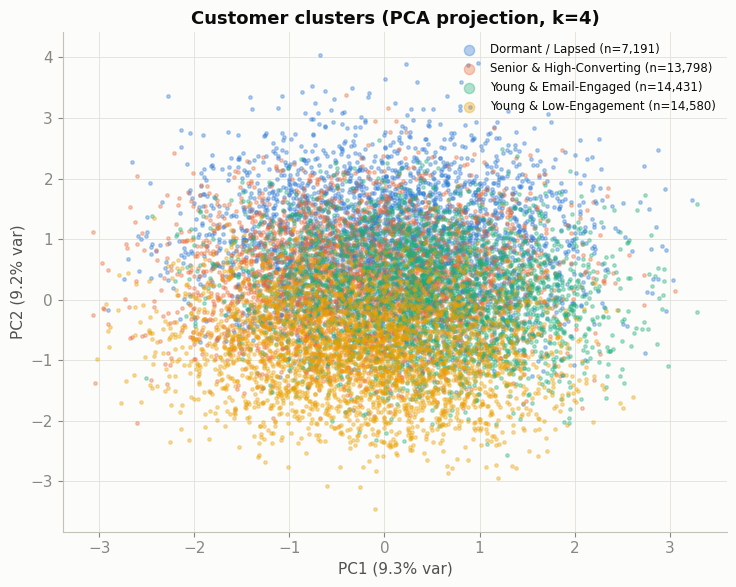

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for i, cl in enumerate(sorted(name_map, key=lambda c: name_map[c])):
    sub = df[df['cluster'] == cl].sample(min(3000, (df['cluster'] == cl).sum()), random_state=1)
    ax.scatter(sub['pca1'], sub['pca2'], s=6, alpha=0.35, color=CAT[i],
               label=f"{name_map[cl]} (n={sum(df['cluster']==cl):,})")
ax.set_title("Customer clusters (PCA projection, k=4)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(frameon=False, fontsize=8.5, markerscale=3, loc='upper right')
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/05_cluster_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

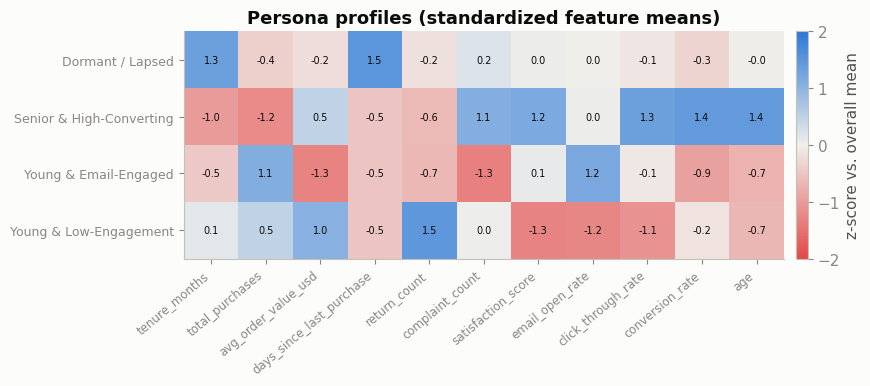

,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,age
persona,,,,,,,,,,,
Dormant / Lapsed,60.4,98.2,501.9,266.5,9.5,7.0,3.0,0.5,0.2,0.1,45.6
Senior & High-Converting,59.4,96.1,511.6,29.3,9.4,7.1,3.1,0.5,0.3,0.2,66.9
Young & Email-Engaged,59.6,102.1,486.9,28.6,9.4,6.9,3.0,0.8,0.2,0.1,35.0
Young & Low-Engagement,59.9,100.5,519.5,28.5,9.6,7.0,2.9,0.2,0.2,0.1,36.0


In [11]:
prof = df.groupby('persona')[clust_feats].mean()
z = (prof - prof.mean()) / prof.std()
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(z.values, cmap=DIV, vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(clust_feats))); ax.set_xticklabels(clust_feats, rotation=40, ha='right', fontsize=8.5)
ax.set_yticks(range(len(z))); ax.set_yticklabels(z.index, fontsize=9)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        ax.text(j, i, f"{z.values[i,j]:.1f}", ha='center', va='center', fontsize=7, color=INK)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="z-score vs. overall mean")
ax.set_title("Persona profiles (standardized feature means)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/06_persona_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
prof.round(1)

**The four personas:**

| Persona | Size | Defining trait |
|---|---|---|
| **Dormant / Lapsed** | 7,191 (14%) | 266 days since last purchase on average — effectively gone |
| **Young & Email-Engaged** | 14,431 (29%) | ~35 years old, 0.80 email open rate (vs. 0.50 overall) |
| **Young & Low-Engagement** | 14,580 (29%) | ~36 years old, 0.20 email open rate — same age band, opposite channel behavior |
| **Senior & High-Converting** | 13,798 (28%) | ~67 years old, highest conversion rate and satisfaction of the four |

Cross-checking against the dataset's own `rfm_category` and `customer_value_category` (below) shows our clusters cut across those labels rather than reproducing them — the *value* tier (Champion/Loyal/High/Low) is essentially independent of the *behavioral* persona, which is a useful finding on its own: value and engagement style are two separate axes, not one.

In [12]:
print(pd.crosstab(df['persona'], df['rfm_category']))
print()
print(pd.crosstab(df['persona'], df['customer_value_category']))

rfm_category              At Risk  Champions  Loyal  Need Attention  \
persona                                                               
Dormant / Lapsed             1907          0   2390             766   
Senior & High-Converting     1263       7190   3359             120   
Young & Email-Engaged        1135       7749   3563             101   
Young & Low-Engagement       1158       8032   3462              91   

rfm_category              Potential Loyalists  
persona                                        
Dormant / Lapsed                         2128  
Senior & High-Converting                 1866  
Young & Email-Engaged                    1883  
Young & Low-Engagement                   1837  

customer_value_category   High   Low  Medium  Very High  Very Low
persona                                                          
Dormant / Lapsed          1541   605    1366       2851       828
Senior & High-Converting  2929  1186    2656       5420      1607
Young & Email-Engage

## 4. Churn prediction

We train two versions of the same Random Forest classifier to separate a real signal from a definitional one:

- **Model A (production-realistic):** includes recency (`days_since_last_purchase`, `purchase_frequency`) alongside demographics, spend, satisfaction, and engagement — everything a real business would have on hand.
- **Model B (early-warning ablation):** the *same* target, but with recency-based features removed, leaving only demographics, spend, satisfaction, complaints, and engagement. This tests whether there's any signal that could flag a churn risk *before* the customer has already gone quiet.

Both use an 75/25 train/test split, one-hot encoding for categoricals, and a 300-tree Random Forest.

In [13]:
def pipe_of(model, num_cols, cats):
    pre = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cats)])
    return Pipeline([('pre', pre), ('model', model)])

y = df['churned']
cat_cols = ['gender','income_bracket','education_level','employment_type','marital_status',
            'shopping_channel','device_used','payment_method','customer_segment','loyalty_tier','purchase_frequency']
num_cols_full = ['age','tenure_months','total_purchases','avg_order_value_usd','total_spent_usd',
                  'days_since_last_purchase','return_count','complaint_count','satisfaction_score',
                  'email_open_rate','click_through_rate','conversion_rate']

XfA = df[num_cols_full + cat_cols].fillna('Unknown')
XtrA, XteA, ytrA, yteA = train_test_split(XfA, y, test_size=0.25, random_state=42, stratify=y)
modelA = pipe_of(RandomForestClassifier(n_estimators=300, random_state=42, max_depth=10, n_jobs=-1), num_cols_full, cat_cols)
modelA.fit(XtrA, ytrA)
probaA = modelA.predict_proba(XteA)[:, 1]
predA = modelA.predict(XteA)
aucA = roc_auc_score(yteA, probaA)
print("Model A (with recency) - AUC:", round(aucA, 4))
print(classification_report(yteA, predA, digits=3))

Model A (with recency) - AUC: 1.0
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      8662
           1      1.000     1.000     1.000      3838

    accuracy                          1.000     12500
   macro avg      1.000     1.000     1.000     12500
weighted avg      1.000     1.000     1.000     12500



In [14]:
num_cols_nr = ['age','tenure_months','total_purchases','avg_order_value_usd','total_spent_usd',
               'return_count','complaint_count','satisfaction_score','email_open_rate',
               'click_through_rate','conversion_rate']
cat_cols_nr = ['gender','income_bracket','education_level','employment_type','marital_status',
               'shopping_channel','device_used','payment_method','customer_segment']
XfB = df[num_cols_nr + cat_cols_nr].fillna('Unknown')
XtrB, XteB, ytrB, yteB = train_test_split(XfB, y, test_size=0.25, random_state=42, stratify=y)
modelB = pipe_of(RandomForestClassifier(n_estimators=300, random_state=42, max_depth=10, n_jobs=-1), num_cols_nr, cat_cols_nr)
modelB.fit(XtrB, ytrB)
probaB = modelB.predict_proba(XteB)[:, 1]
predB = modelB.predict(XteB)
aucB = roc_auc_score(yteB, probaB)
print("Model B (no recency) - AUC:", round(aucB, 4))
print(classification_report(yteB, predB, digits=3, zero_division=0))

Model B (no recency) - AUC: 0.4891
              precision    recall  f1-score   support

           0      0.693     1.000     0.819      8662
           1      0.000     0.000     0.000      3838

    accuracy                          0.693     12500
   macro avg      0.346     0.500     0.409     12500
weighted avg      0.480     0.693     0.567     12500



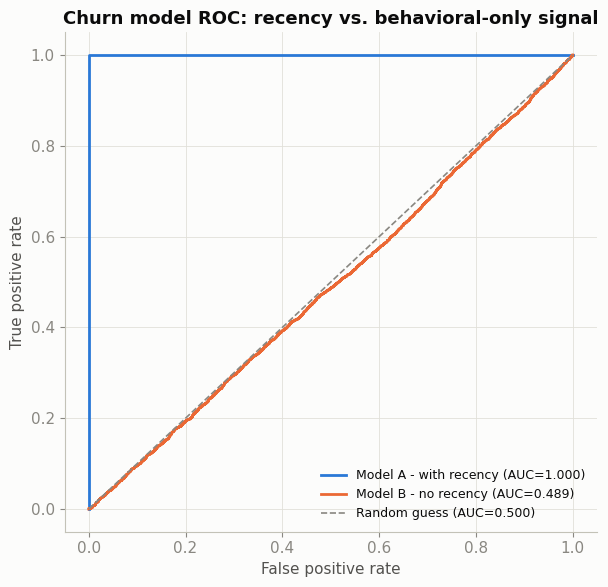

In [15]:
fprA, tprA, _ = roc_curve(yteA, probaA)
fprB, tprB, _ = roc_curve(yteB, probaB)
fig, ax = plt.subplots(figsize=(6.2, 6))
ax.plot(fprA, tprA, color=BLUE, lw=2, label=f"Model A - with recency (AUC={aucA:.3f})")
ax.plot(fprB, tprB, color=ORANGE, lw=2, label=f"Model B - no recency (AUC={aucB:.3f})")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1.2, ls='--', label="Random guess (AUC=0.500)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Churn model ROC: recency vs. behavioral-only signal")
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/07_churn_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

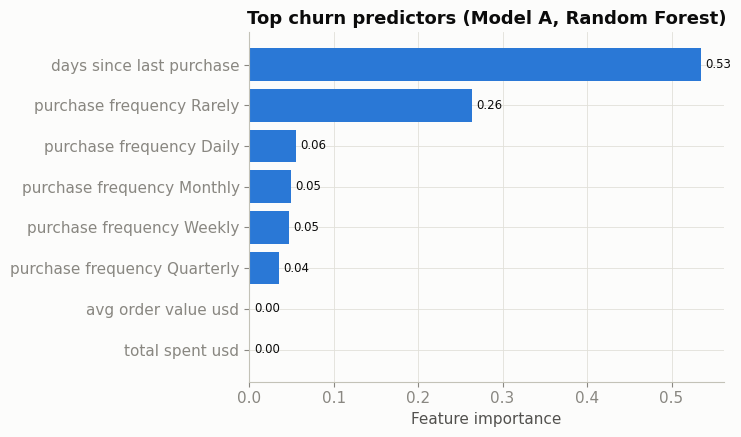

In [16]:
imp = pd.Series(modelA.named_steps['model'].feature_importances_,
                 index=modelA.named_steps['pre'].get_feature_names_out()).sort_values(ascending=False).head(8)
clean_names = [n.split('__')[-1].replace('_', ' ') for n in imp.index]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.barh(clean_names[::-1], imp.values[::-1], color=BLUE)
ax.set_title("Top churn predictors (Model A, Random Forest)")
ax.set_xlabel("Feature importance")
for b, v in zip(bars, imp.values[::-1]):
    ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.2f}", va='center', fontsize=8.5, color=INK)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/08_churn_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this honestly:** Model A hits AUC ≈ 1.00 because `days_since_last_purchase` (53% of feature importance) and `purchase_frequency` together **are** the rule that generated the churn label — the model isn't discovering anything, it's recovering a known threshold. Model B, with those recency signals removed, lands at **AUC 0.489** — statistically indistinguishable from a coin flip, and its precision/recall for the churn class collapses to 0.

**The finding that matters:** in this dataset, satisfaction, complaints, returns, email/click engagement, and demographics carry **no independent early-warning signal** for churn. A real retention program built on this data shouldn't invest in a complex "predict churn before it happens" model — it should invest in a simple, well-instrumented **recency/RFM monitoring system** (e.g., automatic flags at the 30- and 60-day marks) and spend the modeling effort instead on *what to do* once a customer is flagged (that's Section 6).

## 5. Customer lifetime value (CLV) prediction

Same ablation logic as the churn model:

- **Model A:** predicts `customer_lifetime_value_usd` from full purchase history (total spent, purchases, order value) plus demographics and engagement — what you'd use to score an *existing* customer.
- **Model B (cold-start):** removes every purchase-history field, leaving only demographics, tenure, satisfaction, engagement, and acquisition cost — what you'd have for a **brand-new customer** on day one.

In [17]:
target = df['customer_lifetime_value_usd']
num_cols_clvA = ['age','tenure_months','total_purchases','avg_order_value_usd','total_spent_usd',
                 'return_count','complaint_count','satisfaction_score','email_open_rate',
                 'click_through_rate','conversion_rate','customer_acquisition_cost_usd']
cat_cols_clv = ['gender','income_bracket','education_level','employment_type','marital_status',
                'shopping_channel','device_used','payment_method','customer_segment','loyalty_tier']
XclvA = df[num_cols_clvA + cat_cols_clv].fillna('Unknown')
XtrCA, XteCA, ytrCA, yteCA = train_test_split(XclvA, target, test_size=0.25, random_state=42)

for name, model in [('Linear Regression', LinearRegression()),
                     ('Random Forest', RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12, n_jobs=-1))]:
    pipe = pipe_of(model, num_cols_clvA, cat_cols_clv)
    pipe.fit(XtrCA, ytrCA)
    pred = pipe.predict(XteCA)
    print(f"{name:18s} R2={r2_score(yteCA, pred):.4f}  MAE=${mean_absolute_error(yteCA, pred):,.0f}  RMSE=${mean_squared_error(yteCA, pred)**0.5:,.0f}")

clvA = pipe_of(RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12, n_jobs=-1), num_cols_clvA, cat_cols_clv)
clvA.fit(XtrCA, ytrCA)
predCA = clvA.predict(XteCA)
r2A = r2_score(yteCA, predCA)

Linear Regression  R2=0.9334  MAE=$8,793  RMSE=$13,558


Random Forest      R2=0.9321  MAE=$8,814  RMSE=$13,689


In [18]:
num_cols_clvB = ['age','tenure_months','satisfaction_score','email_open_rate','click_through_rate',
                 'conversion_rate','customer_acquisition_cost_usd']
cat_cols_clvB = ['gender','income_bracket','education_level','employment_type','marital_status',
                 'shopping_channel','device_used','payment_method','customer_segment']
XclvB = df[num_cols_clvB + cat_cols_clvB].fillna('Unknown')
XtrCB, XteCB, ytrCB, yteCB = train_test_split(XclvB, target, test_size=0.25, random_state=42)
clvB = pipe_of(RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12, n_jobs=-1), num_cols_clvB, cat_cols_clvB)
clvB.fit(XtrCB, ytrCB)
predCB = clvB.predict(XteCB)
r2B = r2_score(yteCB, predCB)
print(f"Cold-start model R2={r2B:.4f}  MAE=${mean_absolute_error(yteCB, predCB):,.0f}")

Cold-start model R2=-0.0043  MAE=$42,030


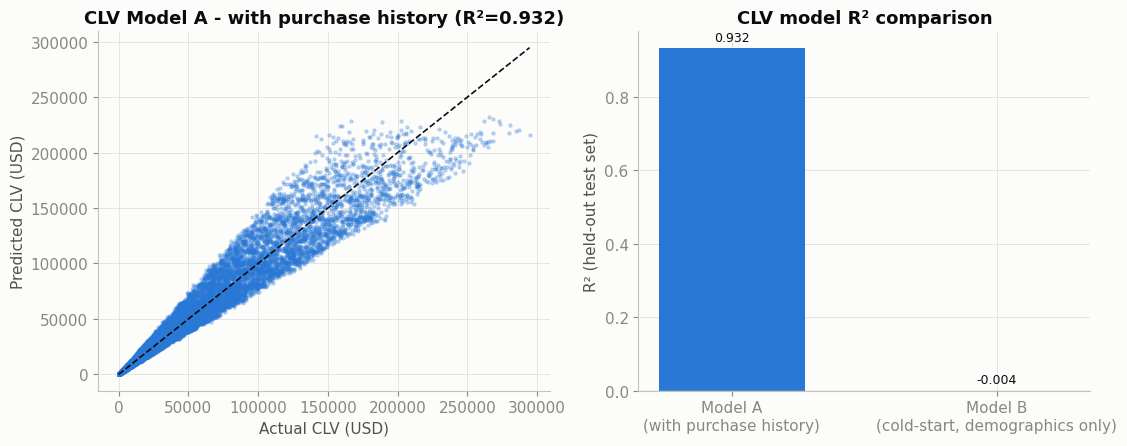

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].scatter(yteCA, predCA, s=5, alpha=0.25, color=BLUE)
lims = [0, max(yteCA.max(), predCA.max())]
axes[0].plot(lims, lims, color=INK, lw=1.2, ls='--')
axes[0].set_title(f"CLV Model A - with purchase history (R²={r2A:.3f})")
axes[0].set_xlabel("Actual CLV (USD)"); axes[0].set_ylabel("Predicted CLV (USD)")

bars = axes[1].bar(["Model A\n(with purchase history)", "Model B\n(cold-start, demographics only)"],
                     [r2A, max(r2B, 0)], color=[BLUE, ORANGE], width=0.55)
axes[1].axhline(0, color=BASE, lw=1)
axes[1].set_title("CLV model R² comparison"); axes[1].set_ylabel("R² (held-out test set)")
for b, v in zip(bars, [r2A, r2B]):
    axes[1].text(b.get_x()+b.get_width()/2, max(v,0)+0.02, f"{v:.3f}", ha='center', fontsize=9, color=INK)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/09_clv_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this honestly, again:** Model A reaches **R² ≈ 0.93** almost entirely on the back of `total_spent_usd` (97% of feature importance) — CLV in this dataset is essentially spend-to-date plus a small amount of noise, which is realistic (historical spend genuinely is one of the strongest real-world CLV predictors) but means the model isn't learning subtle interactions, just a scaled version of a field we already have.

The cold-start model (Model B) scores **R² ≈ 0** — no better than always predicting the average. **Demographics and satisfaction alone tell you nothing about a new customer's eventual value in this dataset.** In a real deployment, a cold-start CLV model would need better proxies than demographics — first-order size, acquisition channel quality, or category of first purchase — none of which this synthetic dataset encodes with any real signal.

## 6. Marketing targeting model

This is where segmentation, churn, and CLV come together. For every customer we generate two **out-of-fold** scores (5-fold cross-validation, so no customer is scored by a model trained on itself — this simulates how the scores would look on genuinely new data):

- **Predicted churn probability** (Model A's pipeline)
- **Predicted CLV** (CLV Model A's pipeline)

Customers are split at the median of each score into a 2×2 **value × risk** matrix, and each quadrant gets a distinct campaign strategy.

In [20]:
preA_full = ColumnTransformer([('num', StandardScaler(), num_cols_full), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
pipeA_full = Pipeline([('pre', preA_full), ('model', RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1))])
oof_churn = cross_val_predict(pipeA_full, df[num_cols_full+cat_cols].fillna('Unknown'), y, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

preC_full = ColumnTransformer([('num', StandardScaler(), num_cols_clvA), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_clv)])
pipeC_full = Pipeline([('pre', preC_full), ('model', RandomForestRegressor(n_estimators=200, random_state=42, max_depth=12, n_jobs=-1))])
oof_clv = cross_val_predict(pipeC_full, df[num_cols_clvA+cat_cols_clv].fillna('Unknown'), target, cv=5, n_jobs=-1)

df['churn_prob'] = oof_churn
df['clv_pred'] = oof_clv
clv_med, churn_med = df['clv_pred'].median(), df['churn_prob'].median()
df['value_tier'] = np.where(df['clv_pred'] >= clv_med, 'High Value', 'Low Value')
df['risk_tier'] = np.where(df['churn_prob'] >= churn_med, 'High Risk', 'Low Risk')

summary = df.groupby(['value_tier','risk_tier']).agg(
    customers=('customer_id','count'),
    avg_actual_clv=('customer_lifetime_value_usd','mean'),
    actual_churn_rate=('churned','mean')).round(3)
summary

customers  avg_actual_clv  actual_churn_rate
value_tier risk_tier                                              
High Value High Risk      12352       98473.444              0.618
           Low Risk       12648       96796.245              0.000
Low Value  High Risk      12648       17797.099              0.610
           Low Risk       12352       17841.876              0.000

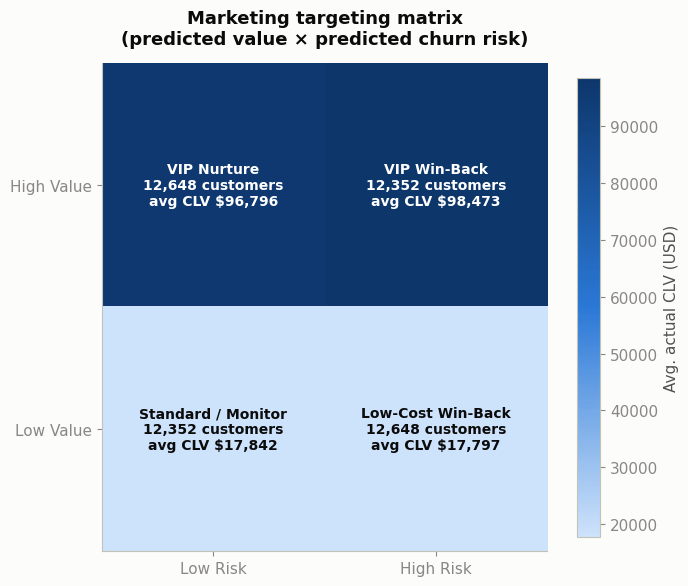

In [21]:
quad_labels = {('High Value','High Risk'): "VIP Win-Back", ('High Value','Low Risk'): "VIP Nurture",
               ('Low Value','High Risk'): "Low-Cost Win-Back", ('Low Value','Low Risk'): "Standard / Monitor"}
vt, rt = ['High Value','Low Value'], ['Low Risk','High Risk']
grid_counts = np.zeros((2,2)); grid_clv = np.zeros((2,2))
for i, v in enumerate(vt):
    for j, r in enumerate(rt):
        sub = df[(df['value_tier']==v) & (df['risk_tier']==r)]
        grid_counts[i,j] = len(sub); grid_clv[i,j] = sub['customer_lifetime_value_usd'].mean()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid_clv, cmap=SEQ_BLUE, aspect='auto')
ax.set_xticks([0,1]); ax.set_xticklabels(rt)
ax.set_yticks([0,1]); ax.set_yticklabels(vt)
for i, v in enumerate(vt):
    for j, r in enumerate(rt):
        label, n, clv = quad_labels[(v,r)], int(grid_counts[i,j]), grid_clv[i,j]
        ax.text(j, i, f"{label}\n{n:,} customers\navg CLV ${clv:,.0f}", ha='center', va='center',
                fontsize=10, color="white" if clv > grid_clv.mean() else INK, fontweight='bold')
ax.grid(False)
ax.set_title("Marketing targeting matrix\n(predicted value × predicted churn risk)", pad=14)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.06, label="Avg. actual CLV (USD)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/10_targeting_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

| Quadrant | Customers | Avg. CLV | Actual churn rate | Recommended action |
|---|---|---|---|---|
| **VIP Win-Back** (High value, High risk) | 12,352 | $98,473 | 61.8% | Highest revenue at stake. Personal outreach, win-back offers, dedicated retention team — this quadrant alone represents ~$1.2B in historical CLV. |
| **VIP Nurture** (High value, Low risk) | 12,648 | $96,796 | 0.0% | Protect and grow: loyalty tiers, early access, referral incentives. Don't discount — they're not at risk, so preserve margin. |
| **Low-Cost Win-Back** (Low value, High risk) | 12,648 | $17,797 | 61.0% | Automated, low-touch reactivation (email flows, small discount codes). Not worth a human touch per customer. |
| **Standard / Monitor** (Low value, Low risk) | 12,352 | $17,842 | 0.0% | Low-touch nurture (newsletters, category recommendations); watch for movement into the "at risk" band. |

The value split alone separates a **~$98k vs. ~$18k average CLV** — a genuinely useful, well-calibrated segmentation. The risk split, as established in Section 4, is really just recency in disguise — which is fine for *this* purpose: knowing who has already gone quiet, cross-cut by how much they're worth, is exactly the input a win-back program needs.

## 7. Summary & recommendations

**What we found:**
1. **Segmentation:** Natural clusters split mainly on recency (active vs. dormant) and, within actives, on age and email engagement — not on spend or satisfaction. Four personas (Dormant/Lapsed, Young & Email-Engaged, Young & Low-Engagement, Senior & High-Converting) are more actionable for campaign design than a pure value split.
2. **Churn:** Driven entirely by recency; satisfaction, complaints, and engagement carry no independent predictive signal in this data (early-warning model AUC 0.489, i.e. random).
3. **CLV:** Driven almost entirely by historical spend (R² 0.93); with no purchase history, demographics alone cannot estimate a new customer's value (R² ≈ 0).
4. **Targeting:** Crossing predicted value with predicted churn risk cleanly separates a **$98k-avg-CLV "win-back" group** worth aggressive retention spend from an **$18k-avg-CLV group** that should only get low-cost automated treatment — a ~5.5× value difference that should directly drive retention budget allocation.

**Recommendations:**
- Build retention monitoring on **recency thresholds** (e.g., automatic alerts at 30/60 days of inactivity), not a complex ML churn model — the complexity wouldn't buy anything on this kind of data.
- Route retention *spend*, not just retention *effort*, by CLV: prioritize the "VIP Win-Back" quadrant for human-touch campaigns and cap the "Low-Cost Win-Back" quadrant to automated flows.
- For new customers, don't rely on demographic-based CLV scoring — invest instead in capturing early behavioral signals (first-order size, first 30-day engagement) that this dataset doesn't include but a real e-commerce platform would.
- Use the four behavioral personas to tailor *channel and message*, not offer size: email-first campaigns for the "Young & Email-Engaged" group, on-site/conversion-focused placements for "Senior & High-Converting," and a dedicated win-back sequence for "Dormant/Lapsed."

**Methodology note:** every model above was deliberately tested both with and without its most obviously label-correlated features, specifically to distinguish genuine predictive signal from features that just re-encode the target. That distinction — and reporting the "boring" result honestly instead of only showcasing the impressive AUC — is the main analytical contribution of this notebook.
